# Random Walk: TD vs MC comparison

In this notebook we compare the performance of temporal difference (TD(0)) and Monte-Carlo.
The example we consider is a so-called Markov reward process,
i.e. a Markov decision process without actions.

For a more detailed description see Example 6.2, page 125, in Sutton & Barto.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

The environment is a finite, integer random walk of a given length,
with the agent starting in the middle of the way.

Each step they go left or right with equal probability.

The two outermost states (`0` and `length-1`) are terminal.

When the agent enters state `length-1` they receive a reward of +1, anytime else 0.

In [2]:

class RandomWalk:
    def __init__(self, length):
        self.length = length
        self.pos = self.length // 2
    
    def step(self):
        if self.pos == 0 or self.pos == self.length - 1:
            return self.pos, 0
        if np.random.uniform() < 0.5:
            self.pos += 1
        else:
            self.pos -= 1
        reward = 0
        if self.pos == self.length - 1:
            reward = 1
        return self.pos, reward
    
    def reset(self):
        self.pos = self.length // 2
        return self.pos


Set the length of the random walk used below.

In [3]:
LENGTH = 7

Create an instance and test the environment

In [4]:
rw = RandomWalk(LENGTH)

print(rw.reset())
for i in range(5):
    print(rw.step())

3
(2, 0)
(3, 0)
(2, 0)
(3, 0)
(4, 0)


## 1. Monte-Carlo

We implement Monte Carlo prediction, roughly following the pseudo-code on page 92 of [Sutton & Barto](http://incompleteideas.net/book/RLbook2020trimmed.pdf#page=114).
Instead of tracking all returns, we use a constant update rate $\alpha$.
The algorithm is changed by using a constant update rate $\alpha$, rather than averaging over all previous returns.

In [5]:
# Initialize:
# V(s) <- arbitrarily

# Loop forever (for each episode):
    # Generate an episode: S0, A0, R1, S1, A1, R2, ..., ST-1, AT-1, RT
    # G <- 0
    # Loop for each step of episode, t = T-1, T-2, ..., 0:
        # G <- GAMMA * G + Rt+1
        # Unless St appears in S0, A0, S1, A1, ..., St-1, At-1:
            # V(St) <- V(St) + alpha * (G - V(St))

First, we define a helper function to generate an episode.

In [6]:
def generateEpisode(randomWalk: RandomWalk):
    # Reset random walk
    randomWalk.reset()
    
    # Take steps until state is terminal
    path = [randomWalk.pos]
    rewards = [0]
    while True:
        pos, reward = randomWalk.step()
        rewards.append(reward)
        if pos == 0 or pos == randomWalk.length - 1:
            break
        path.append(pos)
    
    return path, rewards

Next, we define the code for a single episode of MC.
The value function is passed as `values` and updated in place.

In [7]:

def monteCarloEpisode(randomWalk: RandomWalk, values, alpha):
    path, rewards = generateEpisode(randomWalk)
    
    # Update values
    T = len(path)
    G = 0
    for t in reversed(range(T)):
        G += rewards[t+1]
        if not path[t] in path[0:t]:
            values[path[t]] += alpha * (G - values[path[t]])


Finally, we perform MC by running many episodes.

In [8]:
# Choose parameters
N_EPISODES = 1000
alpha = 0.02

# Initialize values and random walk
values = [0] * LENGTH
randomWalk = RandomWalk(LENGTH)

# Do monte carlo
for i in range(N_EPISODES):
    monteCarloEpisode(randomWalk, values, alpha)

print(values)


[0, 0.24635108572638376, 0.43131982380268946, 0.5654448323047564, 0.6860495956404682, 0.8526759625241935, 0]


## 2. TD(0)

Here, we implement TD(0).
We start by writing the code for a single episode of TD(0).
The value function is passed as `values` and updated in place.

In [9]:
## TD(0) to estimate value function V

# Algorithm parameter alpha
# Initialize V(s) such that V(terminal)=0
# for each episode do:
    # Initialize S
    # repeat:
        # Take step, observe R, S'
        # V(S) <- V(S) + alpha * (R + V(S') − V (S))
        # S <- S'
    # until S is terminal

In [10]:

def tdEpisode(randomWalk: RandomWalk, values, alpha):
    # Initialize new random walk etc.
    randomWalk.reset()

    # Generate an episode, updating values in the process
    while True:
        oldPos = randomWalk.pos
        newPos, reward = randomWalk.step()
        values[oldPos] += alpha * (reward + values[newPos] - values[oldPos])
        if newPos == 0 or newPos == randomWalk.length - 1:
            break


In [11]:
# Choose parameters
N_EPISODES = 1000
alpha = 0.02

# Initialize values and random walk
values = [0] * LENGTH
randomWalk = RandomWalk(LENGTH)

# Do TD(0)
for i in range(1000):
    tdEpisode(randomWalk, values, alpha)

print(values)

[0, 0.16874718424201726, 0.35224298661817527, 0.516783539059994, 0.7268525691093564, 0.8647398874926603, 0]


## Comparison

Note that the true value of state $s$ is $s / (LENGTH - 1)$.
We use this to compare the error produced by each method.

In [12]:
TRUE_VALUES = [i / (LENGTH - 1) for i in range(LENGTH)]

def computeRMS(values):
    errors = [v - t for v, t in zip(values[1:-1], TRUE_VALUES[1:-1])]
    return np.sqrt(np.mean(np.square(errors)))

First we recreate the left graph from p. 125, Sutton & Barto, showing the value function for different numbers of episodes $n$.

In [13]:
def plotValueSteps(showN, alpha, doEpisode):
    values = [0.5] * LENGTH
    values[0] = 0
    values[-1] = 0

    randomWalk = RandomWalk(LENGTH)
    
    n = np.max(showN) + 1
    
    # Perform TD, plotting the values of steps in showN
    for i in range(n):
        if i in showN:
            plt.plot(values[1:-1], label="n = " + str(i))
        doEpisode(randomWalk, values, alpha)
    
    plt.plot(TRUE_VALUES[1:-1], linestyle='dashdot', label="true values")

    plt.legend()
    plt.show()

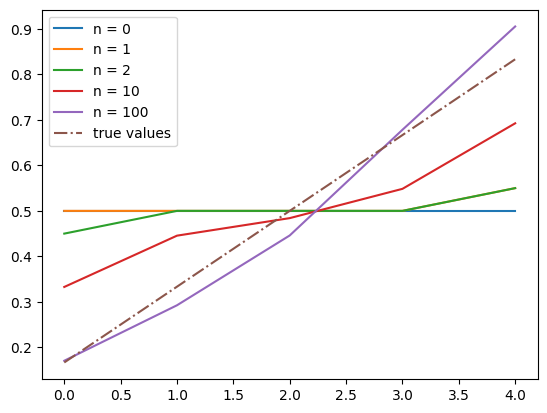

In [14]:
# plotValueSteps([0, 1, 2, 10, 100], 0.1, monteCarloEpisode)
plotValueSteps([0, 1, 2, 10, 100], 0.1, tdEpisode)

Next, we define a function that performs several TD/MC episodes and computes the RMS after each episode.

In [15]:

def computeRMSs(alpha, nEpisodes, doEpisode):
    randomWalk = RandomWalk(LENGTH)
    rms = []
    values = [0.5] * LENGTH
    values[0] = 0
    values[-1] = 0
    for j in range(nEpisodes):
        doEpisode(randomWalk, values, alpha)
        rms.append(computeRMS(values))
    return rms


Using the function above,
we plot the RMS vs. the number of training episodes for both methods and different values of `alpha`.

MC...
0.01
0.02
0.03
0.2
TD...
0.01
0.02
0.03
0.2


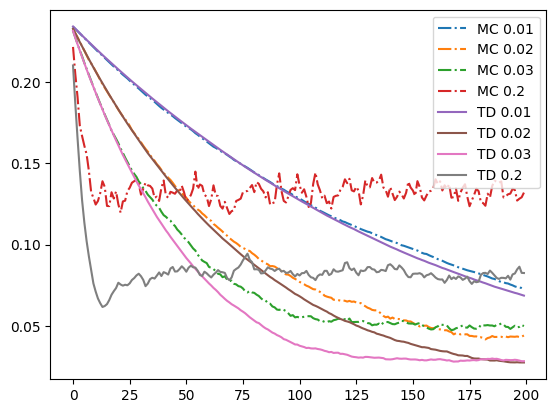

In [16]:

# Compared alphas
alphasMC = [0.01, 0.02, 0.03, 0.20]
alphasTD = [0.01, 0.02, 0.03, 0.20]

# Number of episodes per experiment
nEpisodes = 200

# Number of experiments
nExperiments = 100

print('MC...')
for i, alpha in enumerate(alphasMC):
    print(alpha)
    rmsList = [computeRMSs(alpha, nEpisodes, monteCarloEpisode) for _ in range(nExperiments)]
    rms = np.mean(rmsList, axis=0)
    plt.plot(rms, linestyle='dashdot', label='MC {}'.format(alpha))

print('TD...')
for i, alpha in enumerate(alphasTD):
    print(alpha)
    rmsList = [computeRMSs(alpha, nEpisodes, tdEpisode) for _ in range(nExperiments)]
    rms = np.mean(rmsList, axis=0)
    plt.plot(rms, linestyle='solid', label='TD {}'.format(alpha))


plt.legend()
plt.show()
